# Graphe Hydrographique

## Import des librairies

In [46]:
import pathlib
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pyproj
import networkx as nx
from shapely import Point, LineString, MultiLineString, GeometryCollection, STRtree
from shapely.ops import split, snap, linemerge, unary_union
from tqdm.auto import tqdm
from shapely import box
import shapely
import pickle
from collections import deque

# I. Première tentative avec Cours d'eau comme base

### Pré traitement des données

In [2]:
gdf_ce = gpd.read_file("données hackaton/CoursEau/CoursEau_FXX.shp")

Code_OH = "03C00000020008"

m = gdf_ce['CdOH'].str.startswith(Code_OH)
seine_ce = gdf_ce[m].copy()

In [41]:
sites_ce = gpd.read_file("données hackaton/Sites/Sites.shp")

In [42]:
seine_ce1 = seine_ce.explode(ignore_index = True)

In [43]:
sites_ce1 = sites_ce[~sites_ce.is_empty]

In [45]:
pos1, pos2 = seine_ce1.sindex.nearest(sites_ce1["geometry"], return_all = False) # récupération des indices des lignstrings les plus proches de chaque station (nos sites)
# pos1 sont nos indices des stations, pos2 les lignstrings.

In [10]:
for idx1, idx2 in zip(pos1, pos2):
    pt = sites_ce1.loc[idx1, "geometry"]
    ls = seine_ce1.loc[idx2, "geometry"]

    proj_pt = ls.interpolate(ls.project(pt)) # projection du point sur la ls pour gérer les décalage, puis ajout du point sur la ls.
    snap_ls = snap(ls, proj_pt, tolerance=0.0001) # on rajoute une brisure à la ligne, pour qu'un nouveau segment brisé dans la ligne ait pour bout la station
    split_ls = split(snap_ls, proj_pt) # on split la ligne en deux à l'endroit de la station
    split_ls = linemerge(split_ls) # on merge les lignes pour que ce soit un multilinestring

    sites_ce1.loc[idx1, "geometry"] = proj_pt # on actualise les coordonnées de la station pour que ça soit dans la ligne
    seine_ce1.loc[idx2, "geometry"] = split_ls # on actualise la ligne pour qu'elle soit brisée à l'endroit de la station

In [11]:
seine_ce1["TopoOH"].head(3)

0                       Vallée des Lavoirs
1                         Bras de l'Esches
2    Cours d'Eau 02 de la Commune de Percy
Name: TopoOH, dtype: object

In [12]:
topo = seine_ce1.loc[seine_ce1.index[pos2], "TopoOH"].drop_duplicates().to_list()
topo # on récupère les noms des rivières/affluents sur lesquel.le.s on a des stations

['la Seine',
 'Dérivation de Chatou',
 'la Marne',
 "l'Oise",
 'Bras de la Seine',
 "l'Yerres",
 'le Réveillon',
 'Bras de la Monnaie',
 "l'Aisne",
 "l'Aube",
 "l'Eure",
 'Bras de Marly',
 'Ecluse de la Grande Motte',
 "l'Yonne",
 'le Tholon',
 'Dérivation de Mericourt']

In [13]:
seine2 = seine_ce1[seine_ce1["TopoOH"].isin(topo)] # on récupère la seine et ses affluents où on a des stations uniquement (donc on vire les inutiles)
seine2.head(3)

,gid,CdOH,TopoOH,SourceNomO,DateCreati,StatutOH,InfluenceM,CaractereP,Commentair,ProjCoordO,geometry
57,56787,03C0000002000813425,Bras de la Seine,BDCarthage,2017/01/24 16:06:18.918,Validé,NaN,NaN,None,RGF93 / Lambert 93,"LINESTRING (765941.3 6821223.3, 765935.9 68212..."
79,42971,03C0000002000847877,Bras de la Seine,BDCarthage,2017/01/24 16:06:18.918,Validé,NaN,NaN,None,RGF93 / Lambert 93,"LINESTRING (601967.4 6879627.9, 601960 6879622..."
80,42972,03C0000002000847878,Bras de la Seine,BDCarthage,2017/01/24 16:06:18.918,Validé,NaN,NaN,None,RGF93 / Lambert 93,"LINESTRING (602421.6 6879459.8, 602281.3 68795..."


Construction d'un premier graphe

In [14]:
G = nx.Graph()

for _, row in tqdm(seine2.iterrows(), total = len(seine2)): # tqdm permet de savoir où on en est dans la progression des itérations
    geom = row.geometry
    for i, j in zip(geom.coords, geom.coords[1:]):
        G.add_edge(i,j, weight = LineString([i,j]).length)
# ajout des arêtes au graphe via leurs noeuds d'extrémités (ce qui permet aussi de construire les points), pondérées par leur longueur

  0%|          | 0/962 [00:00<?, ?it/s]

In [15]:
root_node = sites_ce1.loc[sites_ce1["Libellé"] == "Balise fond", "geometry"]
root_node # récupération de notre station à la base (estuaire de la Seine)

71    POINT (491068.6 6930159.5)
Name: geometry, dtype: geometry

In [16]:
root_node = root_node.squeeze().coords[0]
root_node # on ne garde que le tuple des coordonnées du point

(491068.6, 6930159.499999998)

In [17]:
station_nodes = []
for station in sites_ce1.itertuples(): #itertuples() parcourt les lignes d'un df en leur attribuant un nom
    coord = station.geometry.coords[0] 
    attrs = G.nodes[coord] # vue sur les attributs du noeud lié à la station
    attrs["site_id"] = station.Index # ajout de l'index de la station aux métadata du noeud
    attrs["label"] = station.Libellé # on ajoute aussi le nom de la station
    station_nodes.append(coord) # on garde en mémoire les coordonnées de chaque station

In [18]:
colors = []
for station in station_nodes:
    attrs = G.nodes[station]
    if nx.has_path(G, root_node, station):
        path = nx.shortest_path(G, root_node, station, weight = "weight") # on check s'il existe un chemin de la station à l'estuaire jusqu'à la station vue (mais c'est là qu'on peut avoir un problème avec les discontinuités de lignes de CoursEau)
        colors.append("green")
    else:
        print(f"Pas de chemin entre {root_node} et {station} ({attrs['label']})")
        colors.append("red")

Pas de chemin entre (491068.6, 6930159.499999998) et (661541.1119831252, 6857321.481027052) (Joinville-le-Pont)
Pas de chemin entre (491068.6, 6930159.499999998) et (665629.9923794899, 6861592.949784888) (Neuilly-sur-Marne)
Pas de chemin entre (491068.6, 6930159.499999998) et (662887.495116159, 6856868.711264841) (Parc St Maur)
Pas de chemin entre (491068.6, 6930159.499999998) et (661102.0269408673, 6855508.921306176) (Créteil)
Pas de chemin entre (491068.6, 6930159.499999998) et (758245.0743124629, 6887120.418139262) (Reuil)
Pas de chemin entre (491068.6, 6930159.499999998) et (664592.3, 6859430.999999999) (Charenton (Bry))
Pas de chemin entre (491068.6, 6930159.499999998) et (709786.1919782581, 6872272.923649836) (La Ferté-sous-Jouarre)
Pas de chemin entre (491068.6, 6930159.499999998) et (790855.5834515196, 6878126.470071503) (Matougues)
Pas de chemin entre (491068.6, 6930159.499999998) et (816785.09571794, 6845712.269248725) (Frignicourt)
Pas de chemin entre (491068.6, 6930159.4999

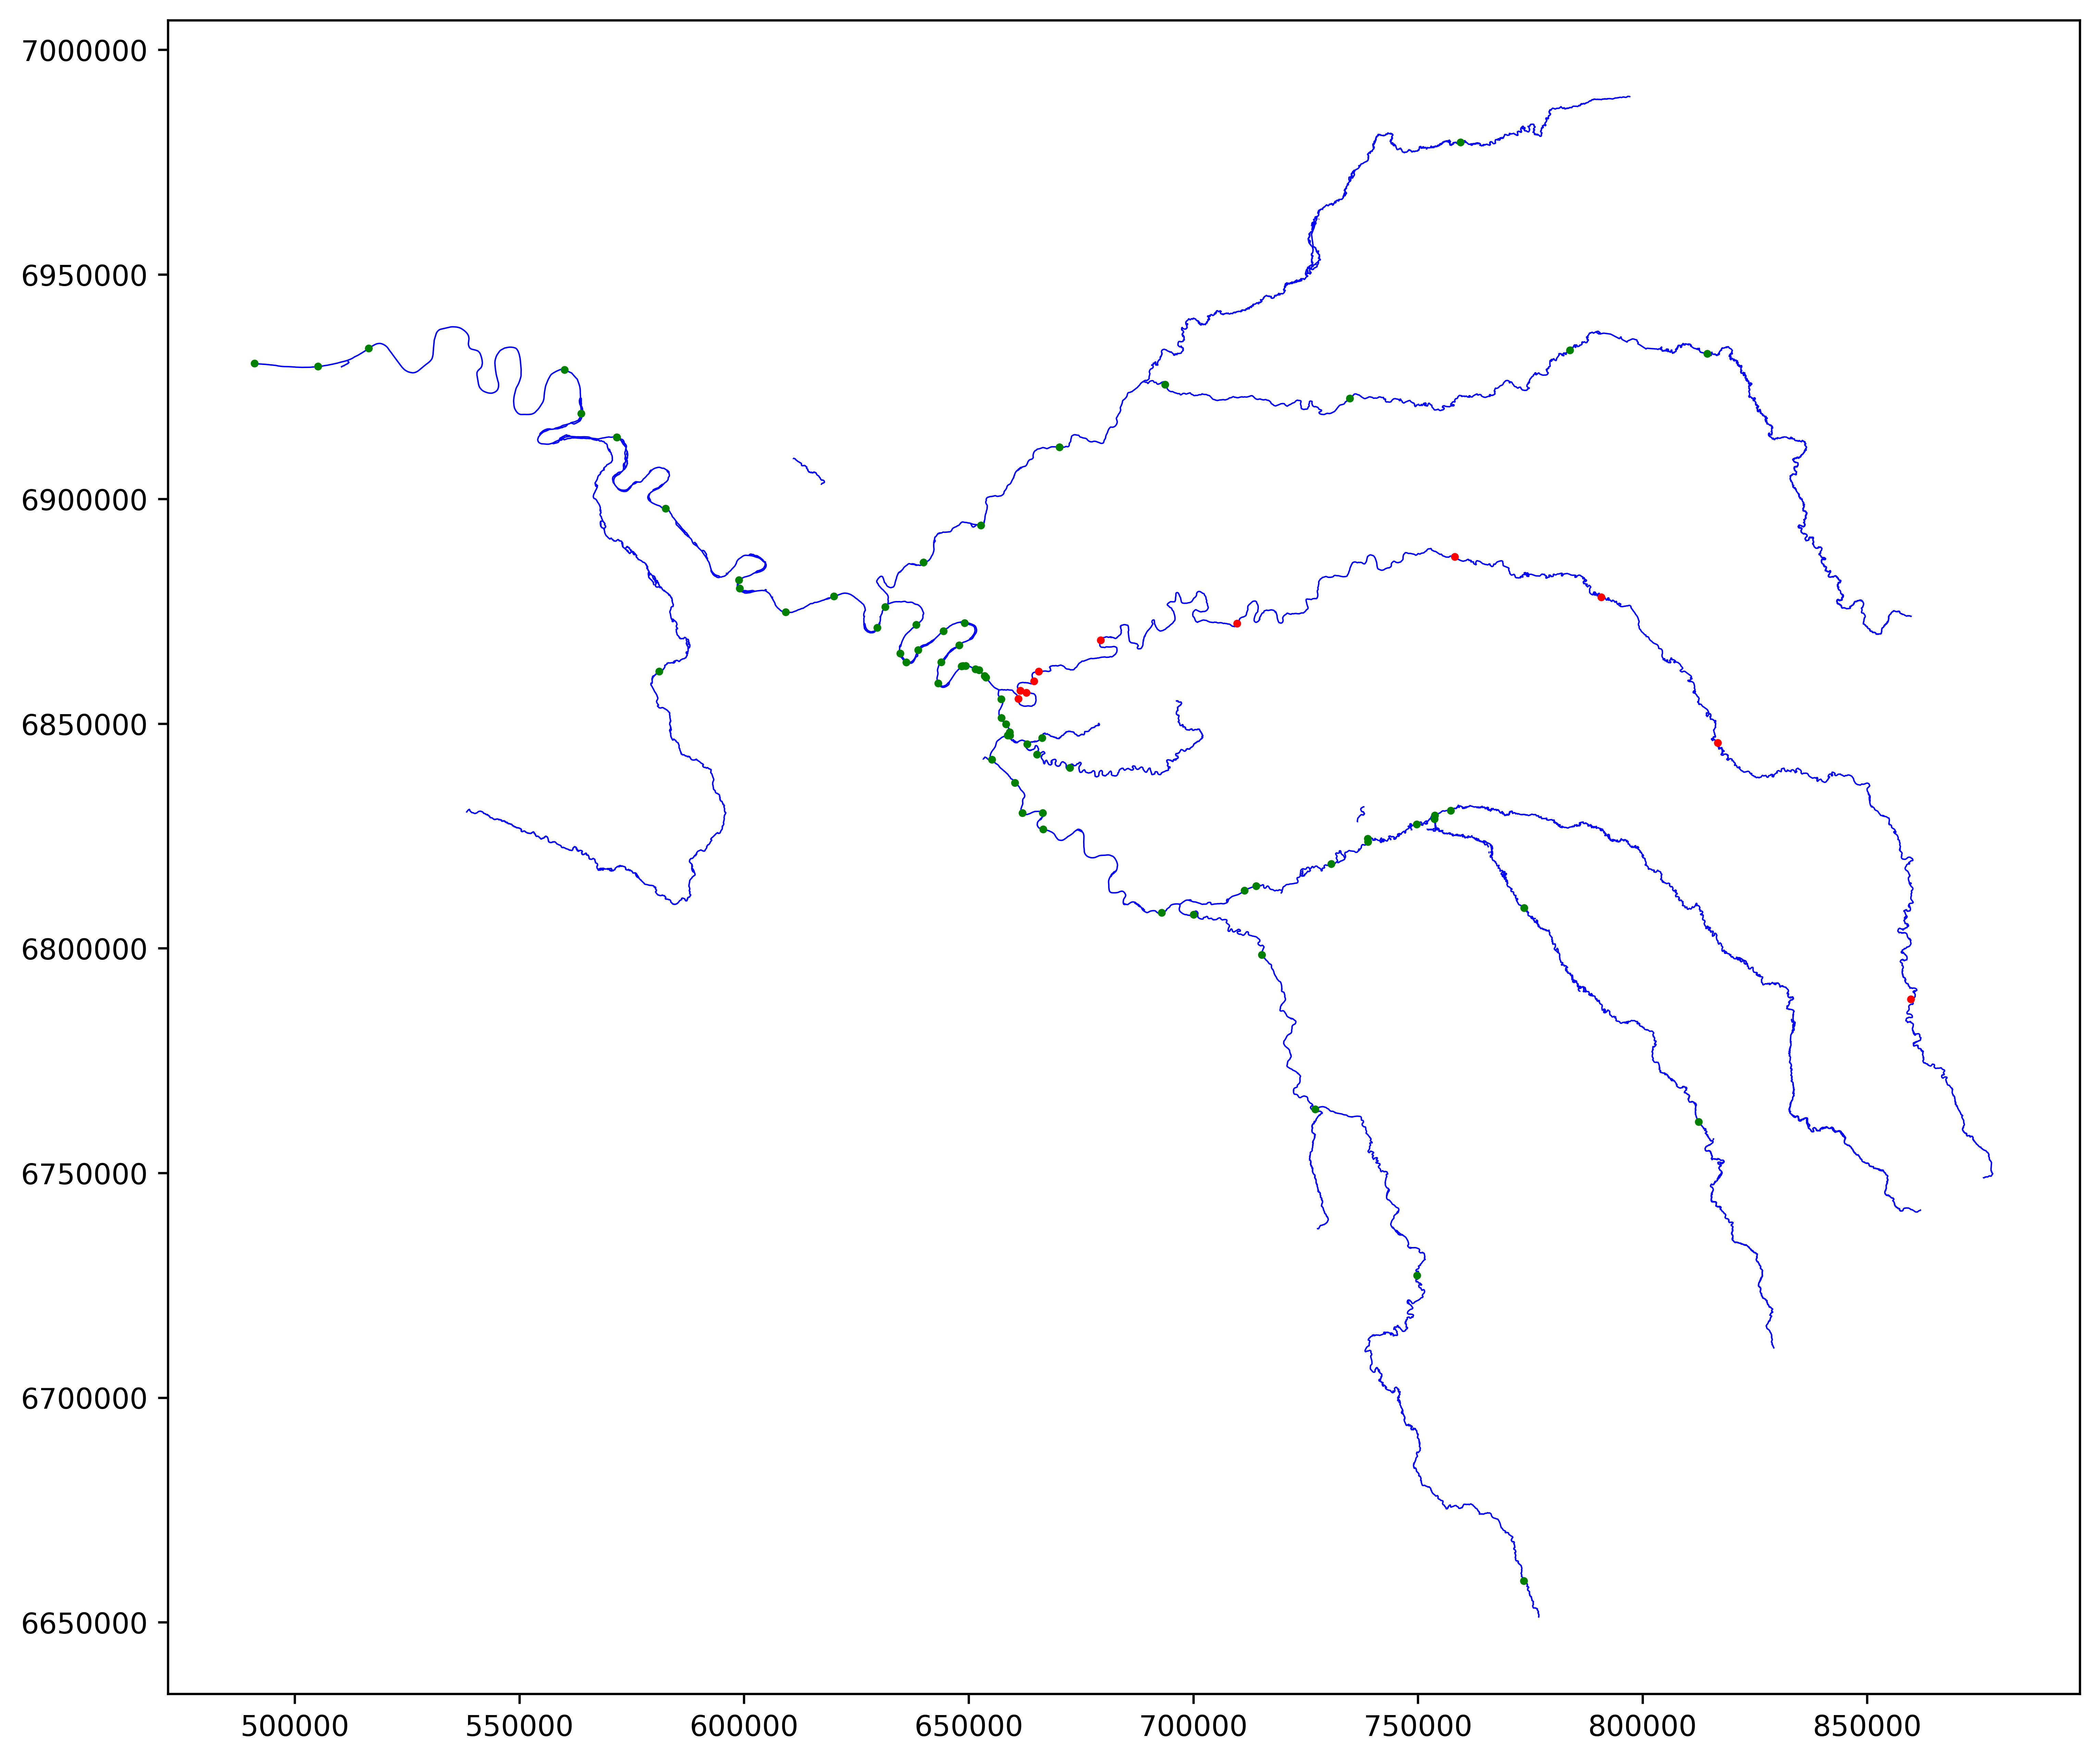

In [19]:
fig, ax = plt.subplots(figsize = (12,12), dpi = 600)
seine2.plot(ax = ax, lw = 0.5, color = "blue", zorder = -1)
sites_ce1.plot(ax = ax, lw = 0.5,color = colors, markersize = 5)
ax.ticklabel_format(style = 'plain', axis = 'both')
plt.show()

# II. Travail avec les tronçons hydrographiques comme base

On fait la même mais en se basant sur la base de données des tronçons hydrographiques cette fois.

In [20]:
Seine_Code = "03C00000020008"

bbox = box(490000, 6658000, 861000, 6981000)
gdf_tr = gpd.read_file(
    "données hackaton/TronconHydrographique/TronconHydrographique_FXX.shp",
    bbox=bbox,
).set_index("CdOH")

patch = {
    "03T0000002287758528": {"TopoOH": "la Marne", "CdCoursEau": "03C0000002000815787"},
    "03T0000002287758537": {"TopoOH": "la Marne", "CdCoursEau": "03C0000002000815787"},
}

gdf_tr.update(pd.DataFrame.from_dict(patch, orient="index"))

m = gdf_tr['CdCoursEau'].fillna("").str.startswith(Seine_Code)
seinetr = gdf_tr[m].copy()
seinetr["geometry"] = seinetr.force_2d()

In [22]:
sites_tr = gpd.read_file("données hackaton/Sites/Sites.shp").to_crs("EPSG:2154")
sites_tr1= sites_tr[~sites_tr.is_empty]

In [23]:
seinetr1 = seinetr.explode(ignore_index = True)

pos1, pos2 = seinetr1.sindex.nearest(sites_tr1["geometry"], return_all = False)

for idx1, idx2 in zip(sites_tr1.index[pos1], seinetr1.index[pos2]):
    pt = sites_tr1.loc[idx1, "geometry"]
    ls = seinetr1.loc[idx2, "geometry"]

    proj_pt = ls.interpolate(ls.project(pt)) 
    snap_ls = snap(ls, proj_pt, tolerance=0.0001) 
    split_ls = split(snap_ls, proj_pt) 
    split_ls = linemerge(split_ls)

    sites_tr1.loc[idx1, "geometry"] = proj_pt 
    seinetr1.loc[idx2, "geometry"] = split_ls

topo = seinetr1.loc[seinetr1.index[pos2], "TopoOH"].drop_duplicates().to_list()
seinetr2 = seinetr1[seinetr1["TopoOH"].isin(topo)]

  0%|          | 0/7157 [00:00<?, ?it/s]

Pas de chemin entre (491068.6, 6930159.499999998) et (759526.6470171005, 6979373.1211244585) (Erloy)
Pas de chemin entre (491068.6, 6930159.499999998) et (773615.649664281, 6659173.638854866) (Château-Chinon)
Pas de chemin entre (491068.6, 6930159.499999998) et (749848.9958628722, 6727159.879115539) (Prégilbert)


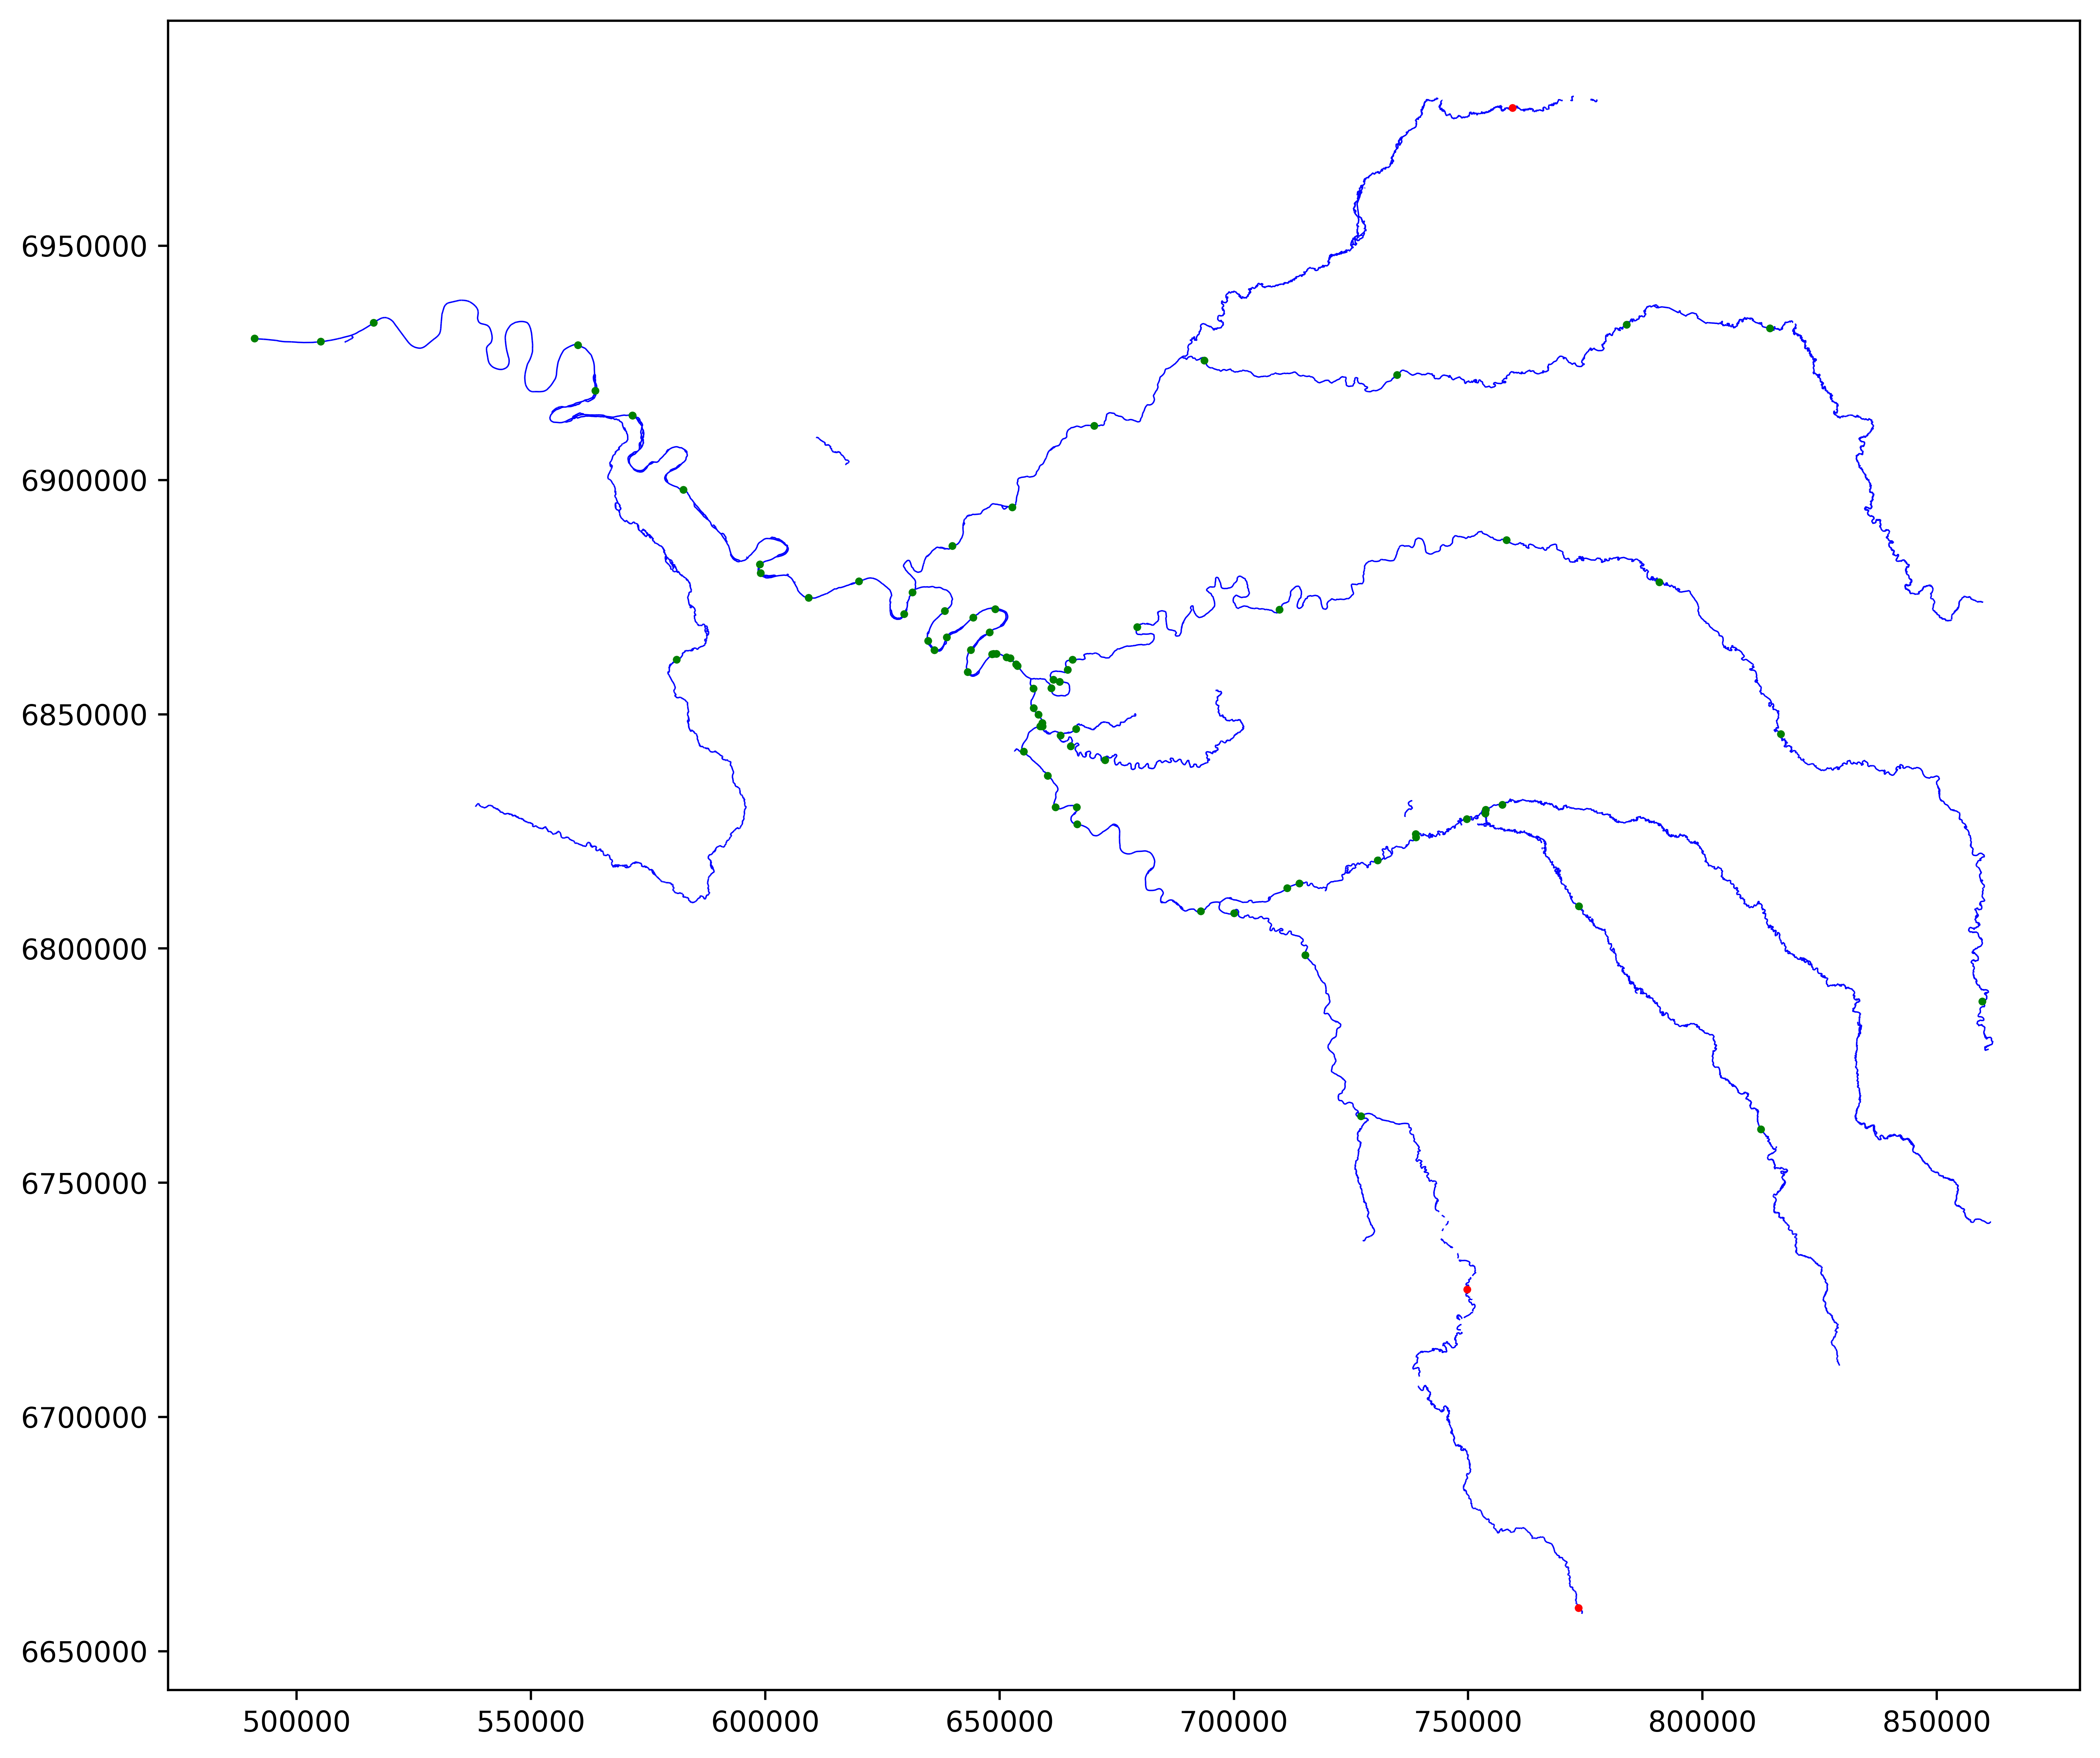

In [24]:
G1 = nx.Graph()

for _, row in tqdm(seinetr2.iterrows(), total = len(seinetr2)): 
    geom = row.geometry
    for i, j in zip(geom.coords, geom.coords[1:]):
        G1.add_edge(i,j, weight = LineString([i,j]).length)

root_node = sites_tr1.loc[sites_tr1["Libellé"] == "Balise fond", "geometry"]
root_node = root_node.squeeze().coords[0]

station_nodes1 = []
for station in sites_tr1.itertuples(): 
    coord = station.geometry.coords[0] 
    attrs = G1.nodes[coord] 
    attrs["site_id"] = station.Index 
    attrs["label"] = station.Libellé 
    station_nodes1.append(coord)

colors1 = []
for station in station_nodes1:
    attrs = G1.nodes[station]
    if nx.has_path(G1, root_node, station):
        path = nx.shortest_path(G1, root_node, station, weight = "weight") # on check s'il existe un chemin de la station à l'estuaire jusqu'à la station vue (mais c'est là qu'on peut avoir un problème avec les discontinuités de lignes de CoursEau)
        colors1.append("green")
    else:
        print(f"Pas de chemin entre {root_node} et {station} ({attrs['label']})")
        colors1.append("red")

fig, ax = plt.subplots(figsize = (12,12), dpi = 600)
seinetr2.plot(ax = ax, lw = 0.5, color = "blue", zorder = -1)
sites_tr1.plot(ax = ax, lw = 0.5,color = colors1, markersize = 5)
ax.ticklabel_format(style = 'plain', axis = 'both')
plt.show()

# III. Ajout de la contraction du graphe

Contraction du graphe pour diminuer sa taille et donc réduire le volume occupé/le temps de traitement.

In [26]:
# définition de la fonction contract

def contract(g):
    """
    Contract chains of neighbouring vertices with degree 2 into a single edge.

    Arguments:
    ----------
    g -- networkx.Graph or networkx.DiGraph instance

    Returns:
    --------
    h -- networkx.Graph or networkx.DiGraph instance
        the contracted graph
    """

    # Travailler sur la version non orientée pour identifier les chaînes
    ug = g.to_undirected() if g.is_directed() else g

    # Créer le sous-graphe des nœuds de degré 2
    is_chain = [node for node, degree in ug.degree() if degree == 2]
    chains = ug.subgraph(is_chain)

    # Correction : connected_component_subgraphs supprimé en NX 2.4+
    # On applique connected_components sur chains (pas sur g)
    components = [chains.subgraph(c) for c in nx.connected_components(chains)]

    hyper_edges = []
    for component in components:
        end_points = [node for node, degree in component.degree() if degree < 2]
        candidates = set(neighbor for node in end_points for neighbor in ug.neighbors(node))
        connectors = list(candidates - set(component.nodes()))
        weights = [data.get('weight', 1) for _, _, data in component.edges(data=True)]
        hyper_edges.append((connectors, np.sum(weights)))

    # Initialiser le nouveau graphe sans les nœuds de degré 2
    not_chain = [node for node in g.nodes() if node not in is_chain]
    h = g.subgraph(not_chain).copy()
    for connectors, weight in hyper_edges:
        # Garde-fou : une chaîne en bout de graphe peut avoir < 2 connecteurs
        if len(connectors) == 2:
            h.add_edge(connectors[0], connectors[1], weight=weight)

    return h

# IV. Concaténation des db Cours d'eau et tronçons hydrographiques (graphe hydrographique connexe)

But de la section : on voit sur les deux exemples faits précédemment avec la Seine que les stations qui ne sont "pas reliées" à l'estuaire sont différentes selon les df utilisés de base. On va donc considérer que merge les deux dataframes permet de combler les gap.

In [27]:
cours_eau_seine = seine_ce.to_crs(2154)
tronçons_seine = seinetr.to_crs(2154)

In [28]:
noded_geometry = unary_union(list(cours_eau_seine.geometry) + list(tronçons_seine.geometry))

if hasattr(noded_geometry, "geoms"):
    lines_list = list(noded_geometry.geoms)
else:
    lines_list = [noded_geometry]

noded_gdf = gpd.GeoDataFrame(geometry=lines_list, crs=2154)

In [29]:
noded_gdf['midpoint'] = noded_gdf.geometry.interpolate(0.5, normalized=True)
noded_gdf_pts = noded_gdf.set_geometry('midpoint')

combined_attributes = pd.concat([cours_eau_seine, tronçons_seine], ignore_index=True)

joined = gpd.sjoin_nearest(noded_gdf_pts, combined_attributes, how='left', max_distance=1.0)
joined = joined[~joined.index.duplicated(keep='first')]  # évite les doublons de jointure à distance égale

if 'geometry_left' in joined.columns:
    combined1 = joined.set_geometry('geometry_left').drop(columns=['midpoint', 'geometry_right'])
else:
    combined1 = joined.set_geometry('geometry').drop(columns=['midpoint'])

combined1 = combined1.reset_index(drop=True)
combined1_exp = combined1.explode(ignore_index=True)

La cellule du dessus compile en 14 minutes et quelques, faut juste être TRES patient.e, et par pitié ne pas la relancer.

In [30]:
pos1, pos2 = combined1_exp.sindex.nearest(sites_tr1["geometry"], return_all=False)

geom_updates = {}
for idx1, idx2 in zip(sites_tr1.index[pos1], combined1_exp.index[pos2]):
    pt = sites_tr1.loc[idx1, "geometry"]
    ls = geom_updates.get(idx2, combined1_exp.loc[idx2, "geometry"])

    proj_pt = ls.interpolate(ls.project(pt))
    snap_ls = snap(ls, proj_pt, tolerance=0.0001)
    split_ls = linemerge(split(snap_ls, proj_pt))

    sites_tr1.loc[idx1, "geometry"] = proj_pt
    geom_updates[idx2] = split_ls

if geom_updates:
    combined1_exp.loc[list(geom_updates.keys()), "geometry"] = list(geom_updates.values())

In [31]:
topo = combined1_exp.loc[combined1_exp.index[pos2], "TopoOH"].drop_duplicates().to_list()
combined12 = combined1_exp[combined1_exp["TopoOH"].isin(topo)]

In [32]:
G2 = nx.Graph()
edges = []

for geom in combined12.geometry.values:
    coords = np.asarray(geom.coords)
    if len(coords) < 2:
        continue
    diffs = coords[1:] - coords[:-1]
    lengths = np.hypot(diffs[:, 0], diffs[:, 1])
    for (x1, y1), (x2, y2), length in zip(coords[:-1], coords[1:], lengths):
        edges.append(((x1, y1), (x2, y2), length))

G2.add_weighted_edges_from(edges)

In [33]:
root_node = sites_tr1.loc[sites_tr1["Libellé"] == "Balise fond", "geometry"]
root_node = root_node.squeeze().coords[0]

station_nodes2 = []
for station in sites_tr1.itertuples():
    coord = station.geometry.coords[0]
    attrs = G2.nodes[coord]
    attrs["site_id"] = station.Index
    attrs["label"] = station.Libellé
    station_nodes2.append(coord)

In [34]:
lengths_dij, paths = nx.single_source_dijkstra(G2, root_node, weight="weight")

colors2 = []
for station in station_nodes2:
    attrs = G2.nodes[station]
    if station in paths:
        colors2.append("green")
    else:
        print(f"Pas de chemin entre {root_node} et {station} ({attrs['label']})")
        colors2.append("red")

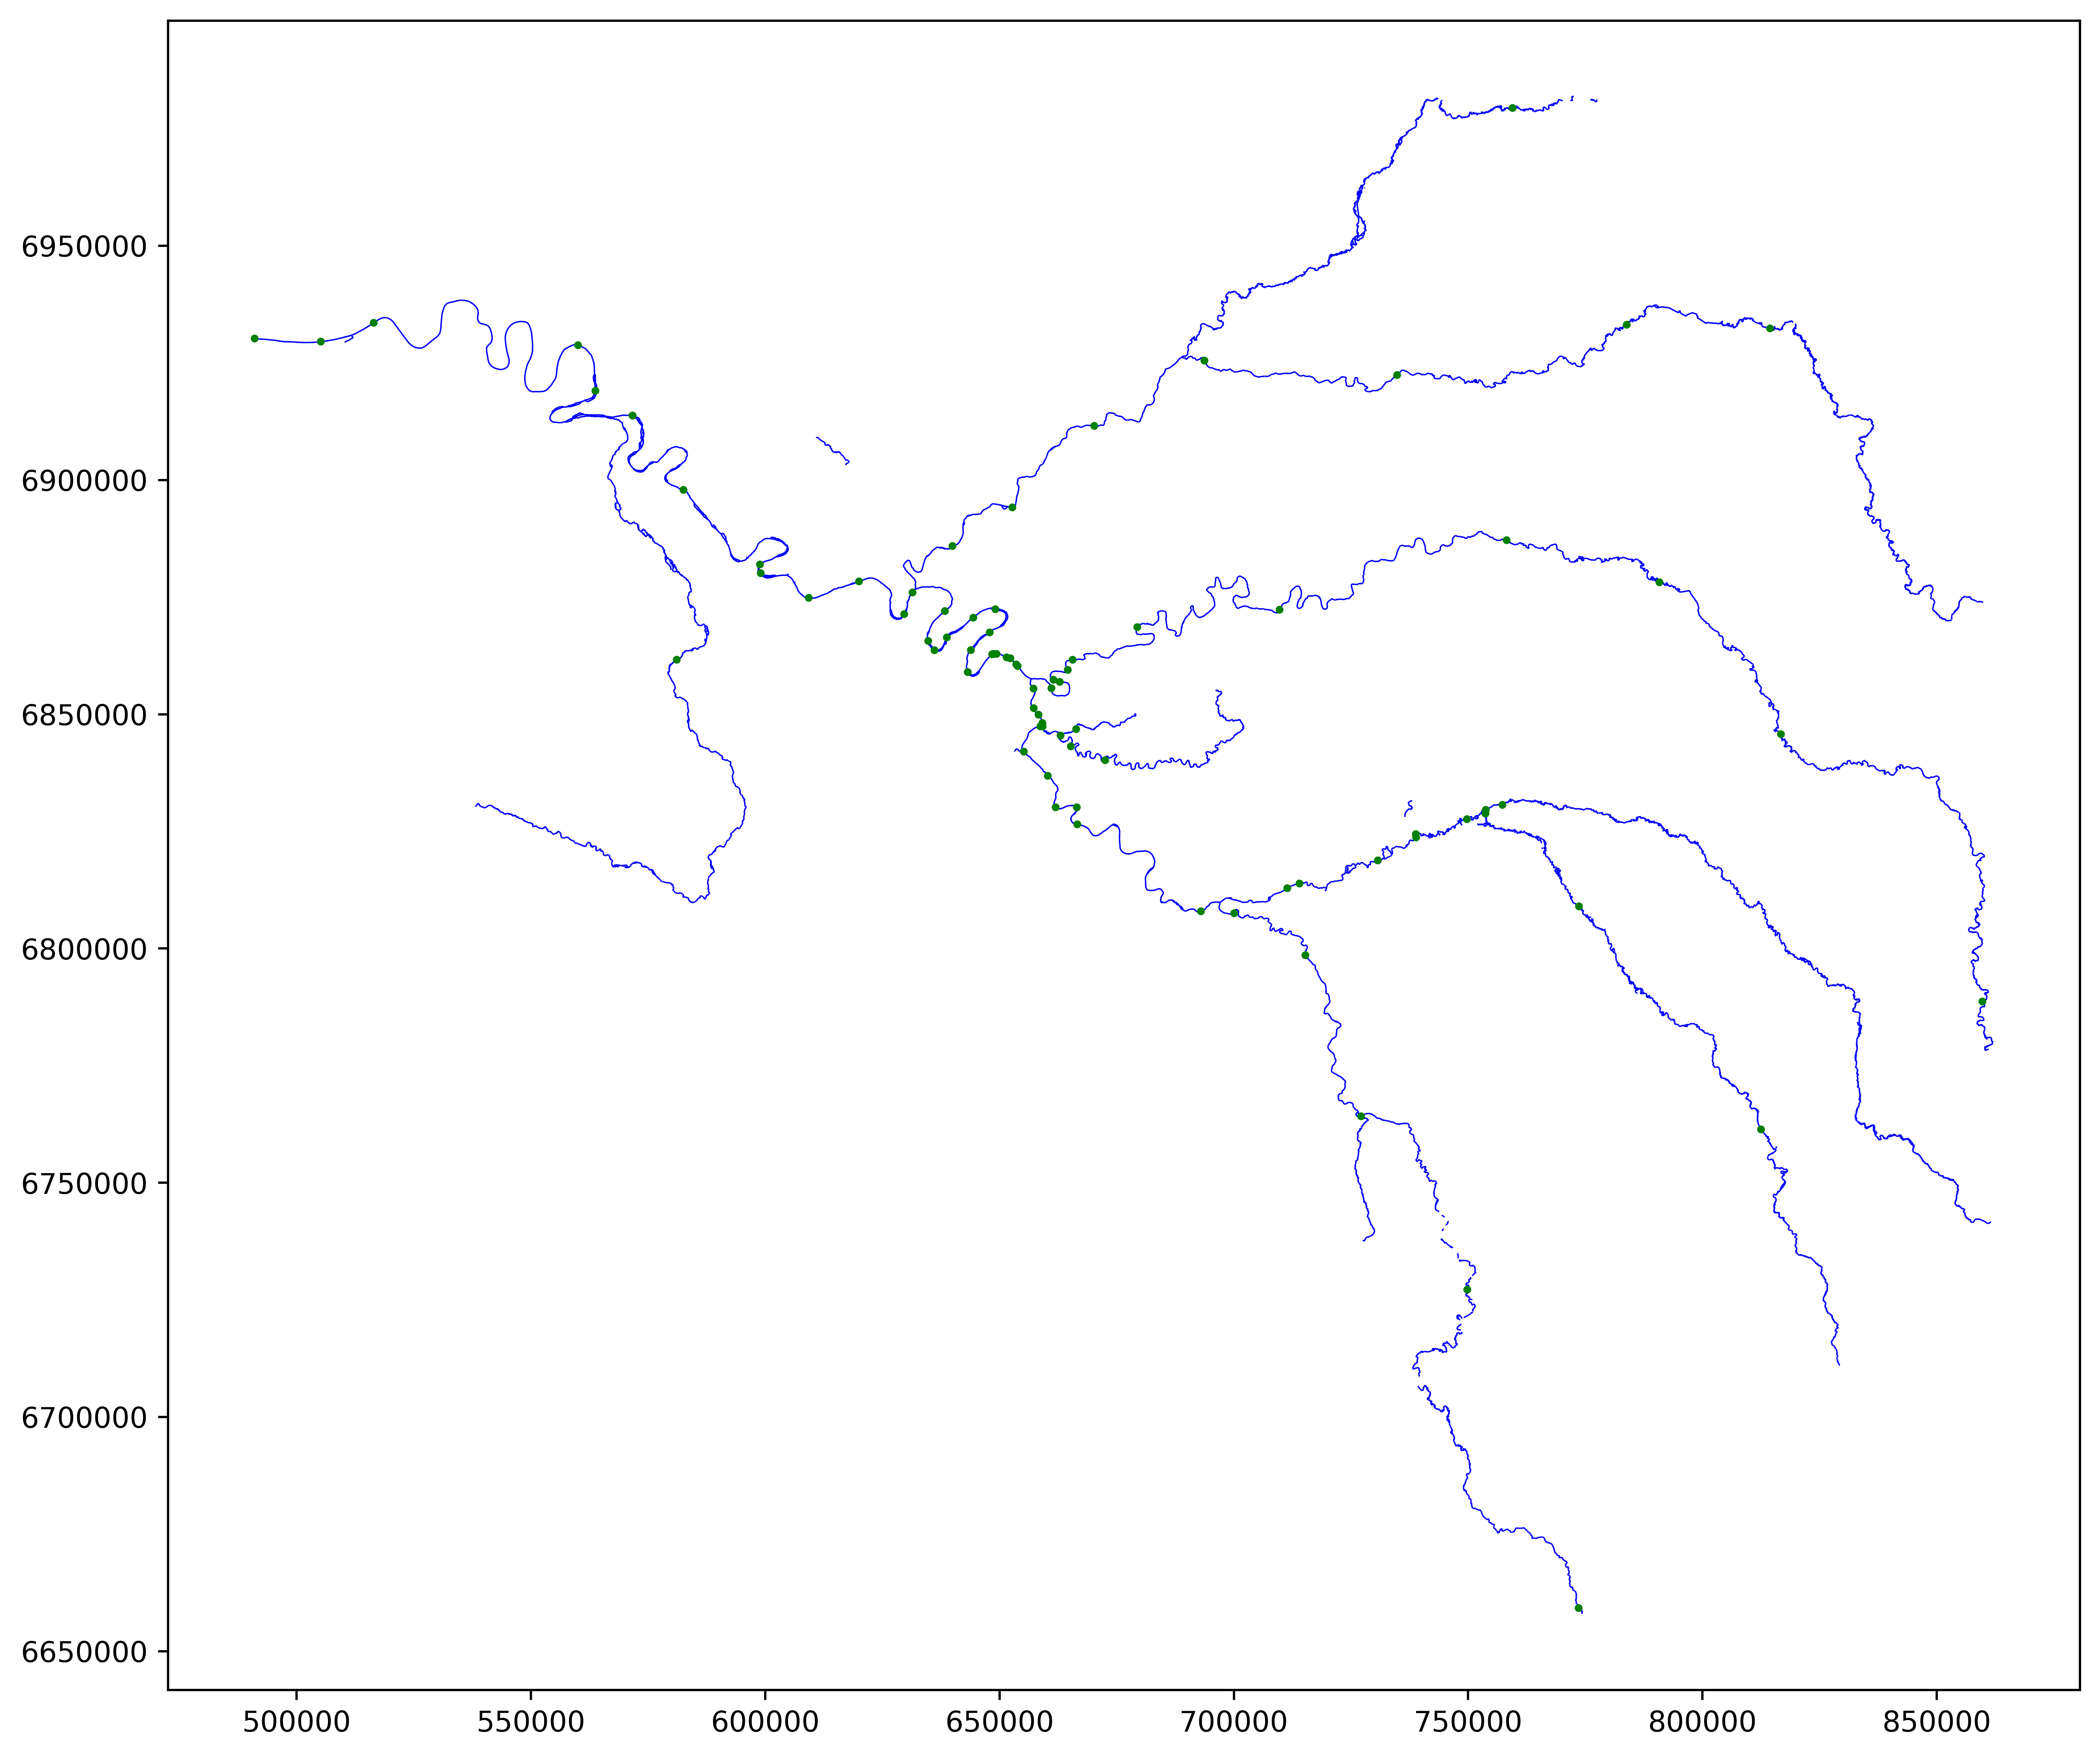

In [36]:
fig, ax = plt.subplots(figsize = (12,12), dpi = 600)
seinetr2.plot(ax = ax, lw = 0.5, color = "blue", zorder = -1)
sites_tr1.plot(ax = ax, lw = 0.5,color = colors2, markersize = 5)
ax.ticklabel_format(style = 'plain', axis = 'both')
plt.show()

Sauvegarde du graphe dans un fichier annexe, pour ne pas avoir à recompiler :

In [40]:
pickle.dump(G2, open('G_connexe_non_contracted.pickle', 'wb'))

Si on fait un groupby sur les CdOH ?

# V. Récupération de l'orientation d'un graphe

Programmation d'une fonction d'orientation du graphe hydrographique, à partir d'un graphe hydrographique CONNEXE non orienté, et de l'exutoire.

In [55]:
def oriente(G, exit):

    oriented = nx.DiGraph()
    oriented.add_node(exit, **G.nodes[exit])

    visited = {exit}
    
    stack = [(exit, None)]

    while stack:
        current, parent_aval = stack.pop()

        for neighbor in G.neighbors(current):
            if neighbor in visited:
                continue 

            visited.add(neighbor)

            edge_data = G.get_edge_data(current, neighbor)
            oriented.add_node(neighbor, **G.nodes[neighbor])
            oriented.add_edge(neighbor, current, **edge_data)

            stack.append((neighbor, current))

    print(len(list(G.nodes))==len(visited))
    return oriented